# Cross-Validation
-Cross-validation is a technique used to check how well a machine learning model performs on unseen data while preventing overfitting<br>
Think of this as "testing the model multiple times on different splits" to ensure it generalizes

## Types
- K-Fold -> splits the dataset into K equal parts, train on k-1, test on 1,  repeat. <br>
         - used mostly for regression datasets
- Stratified K-Fold -> same, but preserves class ratio. <br>
         - used mostly for classification datasets

In [47]:
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier

In [38]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [53]:
data = load_breast_cancer()
X, y = data.data, pd.DataFrame(data.target, columns=['TypeOfCancer'])
print(y.value_counts())
print(y.shape)
print((y.value_counts()[1]/y.shape[0])*100)
print((y.value_counts()[0]/y.shape[0])*100)
print("Class distribution", np.bincount(data.target))

TypeOfCancer
1               357
0               212
Name: count, dtype: int64
(569, 1)
62.741652021089635
37.258347978910365
Class distribution [212 357]


In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape

(455, 30)

In [55]:
model = DecisionTreeClassifier(random_state=42)

In [224]:
# create K-folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=kf)
scores.mean()

# Data is split into 5 parts = 91
# train on k-1, test on 1 = 91 x 4 = 364, 91 
# validation split = 80% and 20%
# each fold gets tested 
# 80
# 80
# 80
# 80
# 20
# -------
# 80 + 5
# 80 + 5
# 80 + 5
# 80 + 5
# each fold is tested once, giving 5 accuracy scores

0.9289561752988048

In [73]:
# Logistic Regression with 5-fold cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
strat_scores = cross_val_score(model, X_train, y_train, cv=skf)
strat_scores.mean()
# this ensures each fold has same ratio of 1, 0 (malignant, not malignant/ benign) cancer samples as the original (67, 33)
# prevents biased results, expecially if one class dominates

0.9340659340659341

# Model Selection (Comparing multiple algorithms)
# model building skills 
- Imagine you have cleaned your data and split it into train, test. Next step is to train the model
# Which model should I use?
Imagine you’ve cleaned your data and are ready to train models.
Now comes the big question:

“Which model should I use?”

There’s no one-size-fits-all algorithm.

Each model learns patterns differently:

Some are simple (Linear Regression)

Some are non-linear (Decision Tree)

Some are ensemble-based (Random Forest, XGBoost)

Some are distance-based (KNN)

Some are margin-based (SVM)

➡️ Model selection = training multiple models and picking the best-performing one.
Ex, Think of your dataset as a lock, and models as different keys.
You try all the keys to find the one that fits best — i.e., gives the highest accuracy or lowest error on unseen data.

In [137]:
# Iris dataset

In [83]:
# importing lib
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [87]:
iris = load_iris()
X, y = iris.data, iris.target

In [91]:
# scale features (specially for KNN and SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [93]:
# models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [99]:
# cross- valid
skf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [103]:
# compare models
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=skf, scoring='accuracy')
    results[name] = scores.mean()

C:\Users\quadi\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\quadi\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\quadi\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\quadi\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\qua

In [105]:
results

{'Logistic Regression': 0.9533333333333334,
 'Decision Tree': 0.9533333333333335,
 'Random Forest': 0.9533333333333335,
 'AdaBoost': 0.9466666666666667,
 'SVM': 0.9533333333333334,
 'KNN': 0.9666666666666666}

In [107]:
# DataFrame
rdf = pd.DataFrame(list(results.items()), columns=['Model','Mean Accuracy'])
rdf = rdf.sort_values(by='Mean Accuracy', ascending = False)
rdf

,Model,Mean Accuracy
5,KNN,0.966667
1,Decision Tree,0.953333
2,Random Forest,0.953333
0,Logistic Regression,0.953333
4,SVM,0.953333
3,AdaBoost,0.946667


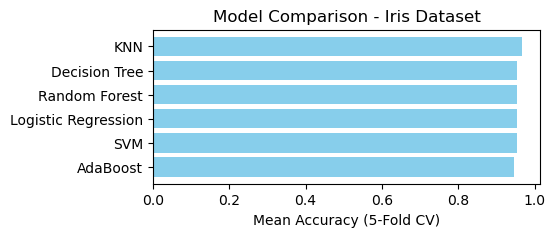

In [204]:
# Visualization
plt.figure(figsize=(5,2))
plt.barh(rdf['Model'], rdf['Mean Accuracy'], color='skyblue')
plt.xlabel("Mean Accuracy (5-Fold CV)")
plt.title("Model Comparison - Iris Dataset")
plt.gca().invert_yaxis()
plt.show()

# 🏋️‍♀️ 8. Mini Assignment

Compare at least 4 regression models (LinearRegression, DecisionTreeRegressor, RandomForestRegressor, SVR)
on the California housing dataset using cross-validation.
Find the one with the lowest RMSE (Root Mean Squared Error).

# SMOTE(Synthetic Minority Oversampling Technique) - Handling Imbalanced Data
# SMOTEEENN or SMOTETomek

ex, When building machine learning models, sometimes one class (say fraudulent transactions, rare disease cases, etc.) appears far less frequently than others.
This creates an imbalanced dataset, where the model becomes biased toward the majority class.

1 - resampling the dataset
  - oversampling - duplicate or generate synthetic minority samples <br>
                 - if the dataset is small with less number of rows
  - undersampling - remove majority class samples <br>
                  - if the dataset is large with many number of rows
2 - changing the evaluation matrix
  - Accuracy is misleading here.
  - Use Precision, Recall, F1-score, or ROC-AUC instead
3 - Algorithmic adjustments
  - some algorithms like RandomForestClassifier support class_weight = 'balanced'

# SMOTE - does not duplicate existing ones
1- it looks at a data point from the minority class
- finds it nearest neighbors(usually 5)
- randomly picks 1 and creates a new point in between them
- new values are generated instead of duplication

In [126]:
from imblearn.over_sampling import SMOTE

In [143]:
# apply smote
smote = SMOTE(random_state=42)
data = load_breast_cancer()
X, y = data.data, pd.DataFrame(data.target, columns=['TypeOfCancer'])

In [145]:
X_res, y_res = smote.fit_resample(X,y)

In [151]:
print(X.shape, y.shape)
print(y.value_counts())

(569, 30) (569, 1)
TypeOfCancer
1               357
0               212
Name: count, dtype: int64


In [155]:
print(X_res.shape, y_res.shape)
print(y_res.value_counts())

(714, 30) (714, 1)
TypeOfCancer
0               357
1               357
Name: count, dtype: int64


In [163]:
# ex with different dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [165]:
# Step 2: Create an imbalanced dataset
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1,
                           weights=[0.9, 0.1], random_state=42)

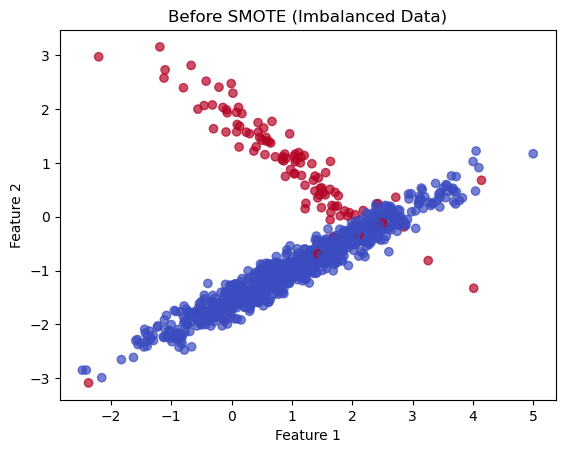

In [172]:
# Visualize imbalance
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title("Before SMOTE (Imbalanced Data)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [184]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [186]:
# Step 5: Train model
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [188]:
# Step 6: Evaluate model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       263
           1       1.00      0.76      0.86        37

    accuracy                           0.97       300
   macro avg       0.98      0.88      0.92       300
weighted avg       0.97      0.97      0.97       300

Confusion Matrix:
 [[263   0]
 [  9  28]]


In [190]:
# Step 3: Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

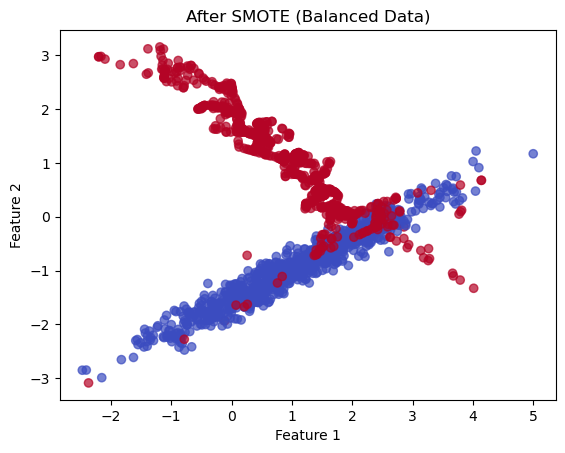

In [192]:
# Visualize new balanced data
plt.scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', alpha=0.7)
plt.title("After SMOTE (Balanced Data)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [194]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

In [196]:
# Step 5: Train model
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [198]:
# Step 6: Evaluate model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       266
           1       0.94      0.89      0.91       271

    accuracy                           0.92       537
   macro avg       0.92      0.92      0.92       537
weighted avg       0.92      0.92      0.92       537

Confusion Matrix:
 [[250  16]
 [ 29 242]]


In [230]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  